### Lab Assignment 4 
Will be working on Dataset Kaggle New York City Airbnb Open Data

Task 1 - Data Analysis and preparation

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x:f"{x:.2f}")
print("Libraries Imported Successfully")

# Loading the dataset
df_airnb = pd.read_csv("AB_NYC_2019.csv")

# Printing the shape of the dataset
shape_dataset = df_airnb.shape
print("Shape of the dataset is",shape_dataset)

# Printing the First 5 data from dataset
print("="*50)
print(df_airnb.head())

print("="*50)
print("Printing the columns names of the dataset")
for i,column in enumerate(df_airnb.columns):
    print(f"{i}:{column}")



Libraries Imported Successfully
Shape of the dataset is (48895, 16)
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington     40.65     -73.97   
1     Jennifer           Manhattan       Midtown     40.75     -73.98   
2    Elisabeth           Manhattan        Harlem     40.81     -73.94   
3  LisaRoxanne            Brooklyn  Clinton Hill     40.69     -73.96   
4        Laura           Manhattan   East Harlem     40.80     -73.94   

         room_type  price  minimum_nights  number_of_reviews last_review

In [4]:
#Operation on the dataset 

# checking the missing values
missing_values = df_airnb.isnull().sum()
missing_percentage = (missing_values/len(df_airnb))*100

missing_df = pd.DataFrame({
    "Missing values":missing_values,
    "Missing Percentage":missing_percentage
})

missing_df = missing_df[missing_df["Missing values"]>0]
missing_df = missing_df.sort_values(by="Missing Percentage",ascending=False)
display(missing_df)


# checking the duplicate values 
duplicate_count = df_airnb.duplicated().sum()
print("Nunber of duplicate rows:",duplicate_count)

if duplicate_count>0:
    df_airnb = df_airnb.drop_duplicates().copy()
    print("Duplicate rows removed")
else:
    print("No duplicate rows found:")

categorical_columns = [
    "neighbourhood_group",
    "room_type"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df_airnb[column].value_counts())
print("Number of unique neighbourhoods:", df_airnb["neighbourhood"].nunique())


print("="*50)
print("Description of Price column")
print(df_airnb["price"].describe())
print("Zero-price listings:", (df_airnb["price"] == 0).sum())
print("Negative-price listings:", (df_airnb["price"] < 0).sum())



,Missing values,Missing Percentage
reviews_per_month,10052,20.56
last_review,10052,20.56
host_name,21,0.04
name,16,0.03


Nunber of duplicate rows: 0
No duplicate rows found:

neighbourhood_group
neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

room_type
room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64
Number of unique neighbourhoods: 221
Description of Price column
count   48895.00
mean      152.72
std       240.15
min         0.00
25%        69.00
50%       106.00
75%       175.00
max     10000.00
Name: price, dtype: float64
Zero-price listings: 11
Negative-price listings: 0


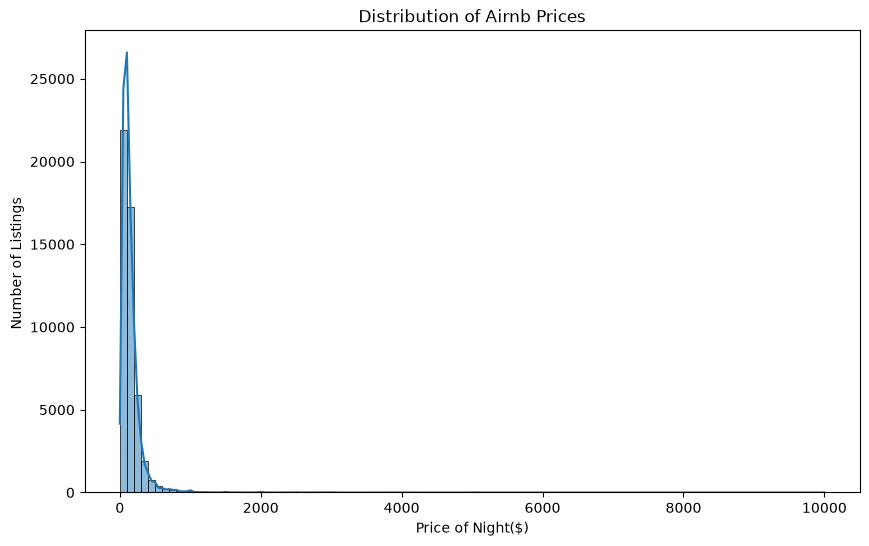

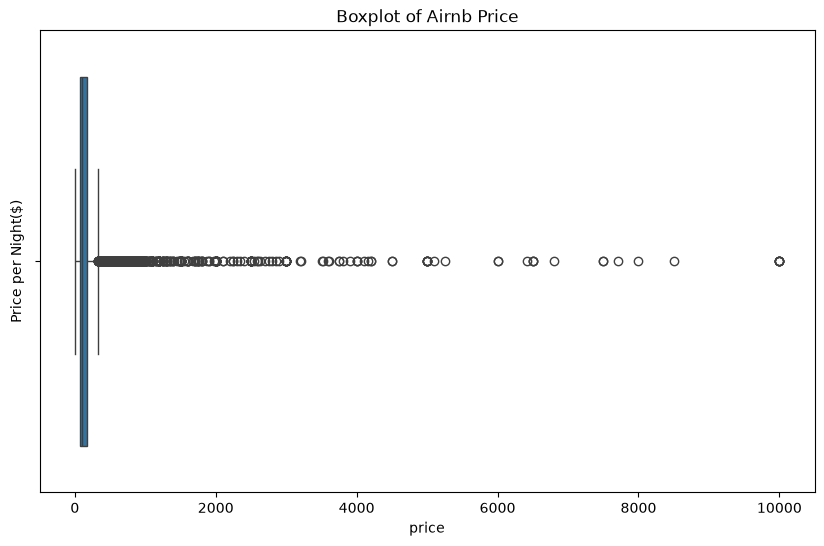

In [14]:
# Plotting the Graph for price column
plt.figure(figsize=(10,6))
sns.histplot(
    df_airnb["price"],
    bins=100,
    kde=True
)

plt.title("Distribution of Airnb Prices")
plt.xlabel("Price of Night($)")
plt.ylabel("Number of Listings ")
plt.show()

# Price Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x=df_airnb["price"])
plt.title("Boxplot of Airnb Price")
plt.ylabel("Price per Night($)")
plt.show()


In [20]:
# Price Outliers 
Q1 = df_airnb["price"].quantile(0.25)
Q3 = df_airnb["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 -1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 is ",Q1)
print ("Q3 is ",Q3)
print ("IQR is ",IQR)
print("Lower Bound is ",lower_bound)
print("Upper Bound is ",upper_bound)


print("="*50)
outliers = df_airnb[
    (df_airnb["price"]<lower_bound) |
    (df_airnb["price"]>upper_bound)
]
print("Number of potential price Outliers:",len(outliers))
print("Percentage of potential Outliers",round(len(outliers)/len(df_airnb)*100,2),"%")
print("="*50)

print()
# Displaying the Expensive things 
print("Displaying the expensive things:-")
display(df_airnb.sort_values("price",ascending=False)[[
    "name","neighbourhood_group","neighbourhood","room_type","price","minimum_nights"
]].head(20))    

Q1 is  69.0
Q3 is  175.0
IQR is  106.0
Lower Bound is  -90.0
Upper Bound is  334.0
Number of potential price Outliers: 2972
Percentage of potential Outliers 6.08 %

Displaying the expensive things:-


,name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights
29238,1-BR Lincoln Center,Manhattan,Upper West Side,Entire home/apt,10000,30
9151,Furnished room in Astoria apartment,Queens,Astoria,Private room,10000,100
17692,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Greenpoint,Entire home/apt,10000,5
6530,Spanish Harlem Apt,Manhattan,East Harlem,Entire home/apt,9999,5
40433,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Lower East Side,Entire home/apt,9999,30
12342,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,Lower East Side,Private room,9999,99
30268,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Manhattan,Tribeca,Entire home/apt,8500,30
4377,Film Location,Brooklyn,Clinton Hill,Entire home/apt,8000,1
29662,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,Upper East Side,Entire home/apt,7703,1
42523,70' Luxury MotorYacht on the Hudson,Manhattan,Battery Park City,Entire home/apt,7500,1


,count,mean,std,min,25%,50%,75%,max
latitude,48895.00,40.73,0.05,40.50,40.69,40.72,40.76,40.91
longitude,48895.00,-73.95,0.05,-74.24,-73.98,-73.96,-73.94,-73.71
minimum_nights,48895.00,7.03,20.51,1.00,1.00,3.00,5.00,1250.00
number_of_reviews,48895.00,23.27,44.55,0.00,1.00,5.00,24.00,629.00
reviews_per_month,38843.00,1.37,1.68,0.01,0.19,0.72,2.02,58.50
calculated_host_listings_count,48895.00,7.14,32.95,1.00,1.00,1.00,2.00,327.00
availability_365,48895.00,112.78,131.62,0.00,0.00,45.00,227.00,365.00
price,48895.00,152.72,240.15,0.00,69.00,106.00,175.00,10000.00


,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price
latitude,1.00,0.08,0.02,-0.02,-0.01,0.02,-0.01,0.03
longitude,0.08,1.00,-0.06,0.06,0.15,-0.11,0.08,-0.15
minimum_nights,0.02,-0.06,1.00,-0.08,-0.12,0.13,0.14,0.04
number_of_reviews,-0.02,0.06,-0.08,1.00,0.55,-0.07,0.17,-0.05
reviews_per_month,-0.01,0.15,-0.12,0.55,1.00,-0.01,0.19,-0.03
calculated_host_listings_count,0.02,-0.11,0.13,-0.07,-0.01,1.00,0.23,0.06
availability_365,-0.01,0.08,0.14,0.17,0.19,0.23,1.00,0.08
price,0.03,-0.15,0.04,-0.05,-0.03,0.06,0.08,1.00


Plotting the correlation matrix on heatmap


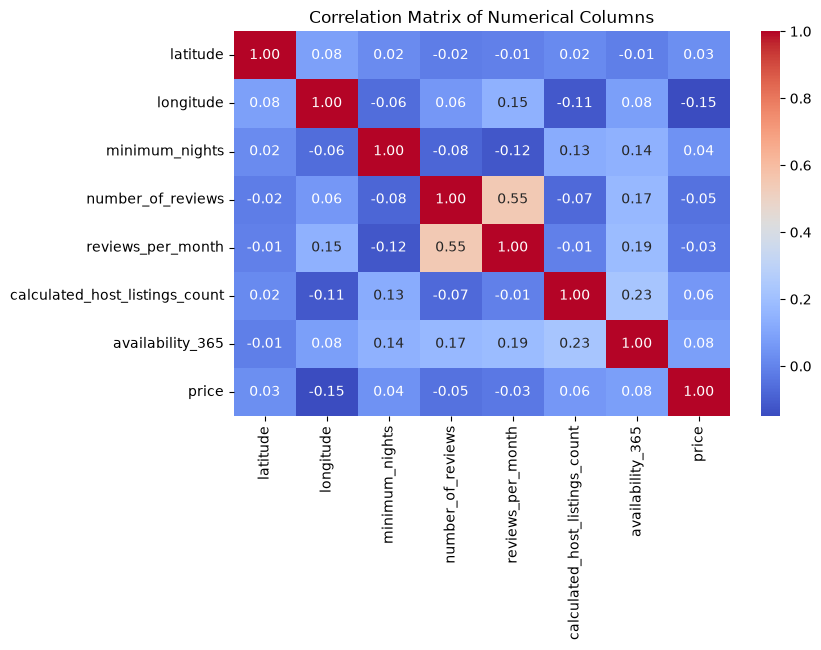

In [44]:
# Displaying the numerical Columns
numerical_columns = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "price"
]
# display(df_airnb)
display(df_airnb[numerical_columns].describe().T)

# Checking the correlation
print()
print("="*150)
correlation_matrix = df_airnb[numerical_columns].corr()
display(correlation_matrix)

# Plotting on graph
print("Plotting the correlation matrix on heatmap")
plt.figure(figsize=(8,5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Columns")
plt.show()


,count,mean,median
room_type,,,
Entire home/apt,25409,211.79,160.00
Private room,22326,89.78,70.00
Shared room,1160,70.13,45.00


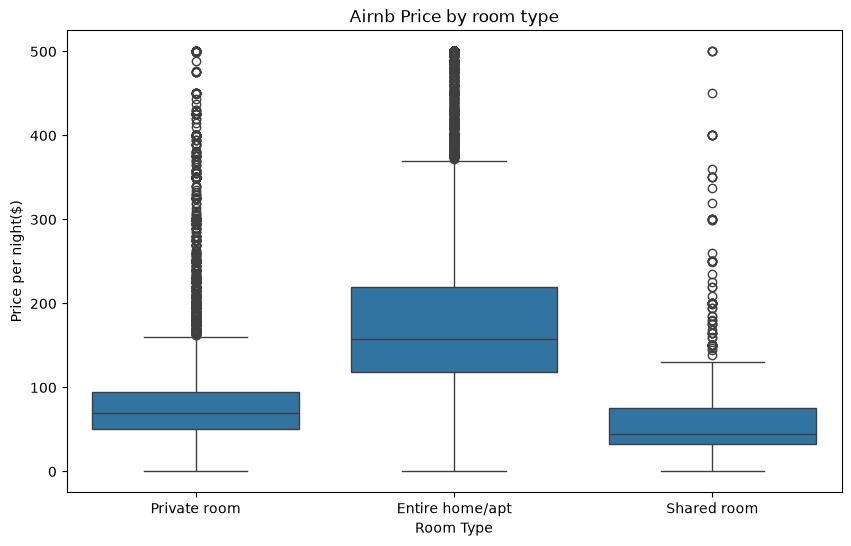

In [49]:
# Calculating the aggregation of the room type by grouping it and providing its summary

room_type_summary = (df_airnb.groupby("room_type")["price"].agg(["count","mean","median"]).sort_values("median",ascending=False))
display(room_type_summary)
print()
# Plotting the points on graph but with a condition that price should be less than 500 so it wont dominate the visualization
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_airnb[df_airnb["price"]<= 500],
    x="room_type",
    y="price"
)
plt.title("Airnb Price by room type")
plt.xlabel("Room Type")
plt.ylabel("Price per night($)")
plt.show()


,count,mean,median
neighbourhood_group,,,
Manhattan,21661,196.88,150.00
Brooklyn,20104,124.38,90.00
Queens,5666,99.52,75.00
Staten Island,373,114.81,75.00
Bronx,1091,87.50,65.00


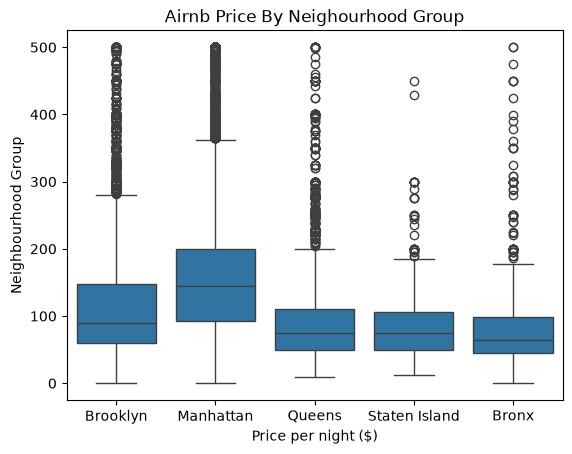

In [52]:
# Aggregating the neighbourhood group and providing its summary like count,mean, median
neighbourhood_summary=(
    df_airnb.groupby("neighbourhood_group")["price"].agg(["count","mean","median"]).sort_values("median",ascending=False)
)
display(neighbourhood_summary)

# Visualizing the neighbourhood Summary
print()
plt.Figure(figsize=(10,6))
sns.boxplot(
    data=df_airnb[df_airnb["price"]<=500],
    x="neighbourhood_group",
    y="price"
)
plt.title("Airnb Price By Neighourhood Group")
plt.ylabel("Neighbourhood Group")
plt.xlabel("Price per night ($)")
plt.show()

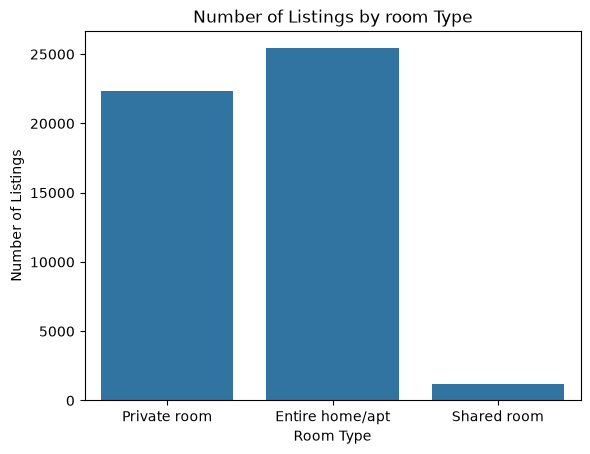

In [53]:
# Number of Listings by Room Type
plt.Figure(figsize=(8,5))
sns.countplot(
    data=df_airnb,
    x="room_type"
)
plt.title("Number of Listings by room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.show()

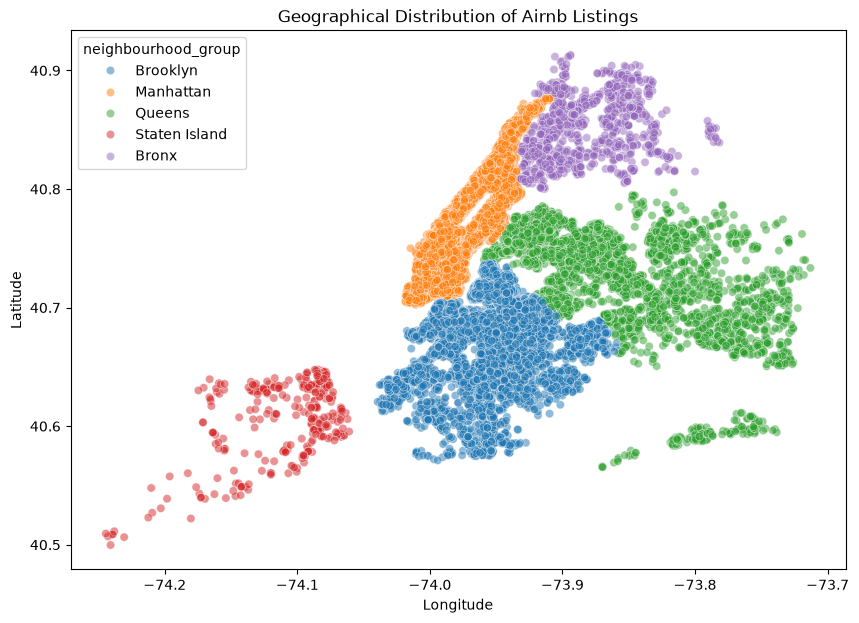

In [ ]:
# Plotting the Geographical Distribution on Scattier Plot
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df_airnb,
    x="longitude",
    y="latitude",
    hue="neighbourhood_group",
    alpha = 0.5
)
plt.title("Geographical Distribution of Airnb Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


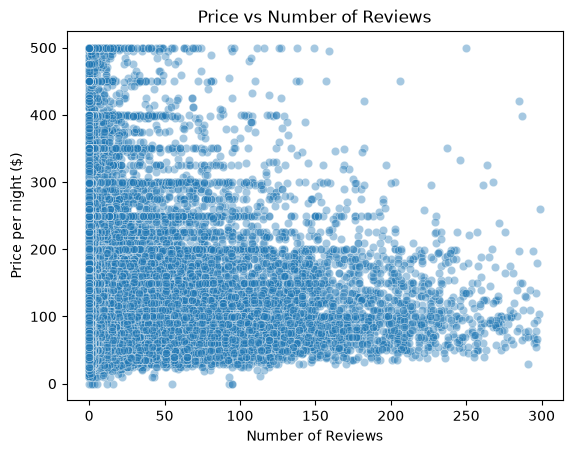

In [59]:
# Price vs Number of reevies
plt.Figure(figsize=(10,7))
plt_data = df_airnb[
    (df_airnb["price"]<=500) &
    (df_airnb["number_of_reviews"]<=300)
    ]
sns.scatterplot(
    data=plt_data,
    x="number_of_reviews",
    y="price",
    alpha=0.4

)
plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price per night ($)")
plt.show()